In [1]:
import json
import os
import re
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcol
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
import sqlalchemy
from lyra_api import LyraAPIClient

from housing_choice.funcs import load_parks

In [2]:
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}",
)

In [4]:
# LYRA_HOST = os.environ["LYRA_HOST"]
LYRA_HOST = "localhost:5219"

client = LyraAPIClient(
    host=LYRA_HOST,
    verbose=True,
    secure="localhost" not in LYRA_HOST,
    headers={
        "P-Access-Token-Id": os.environ["PANGOLIN_ACCESS_TOKEN_ID"],
        "P-Access-Token": os.environ["PANGOLIN_ACCESS_TOKEN"],
    },
)

In [5]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
scripts_path = Path("./scripts")
figure_path = Path("./figures")

In [6]:
df_orig = pd.read_parquet(generated_path / "registro.parquet").assign(
    fraccionamiento=lambda df: df["fraccionamiento"].where(
        lambda x: ~x.str.startswith("privadas condesa"),
        lambda x: x + " (" + df["privada"].str.casefold() + ")",
    ),
)

In [7]:
def fix_condesa_col(x: str) -> str:
    if not x.startswith("privadas condesa"):
        return x

    res = re.search(r"privadas condesa seccion (.+)", x)
    if res is None:
        err = f"Unexpected format for {x}"
        raise ValueError(err)
    name = res.group(1)
    return f"privadas condesa ({name})"


df_col = (
    gpd.read_file(data_path / "initial" / "lim_cols_cp")
    .to_crs("EPSG:6372")
    .dropna(subset=["COLONIAS"])
    .assign(
        COLONIAS=lambda df: (
            df["COLONIAS"]
            .str.casefold()
            .str.replace(r"fracc\.?", "", regex=True)
            .str.replace("fraccionamiento", "")
            .str.strip()
            .replace(
                {
                    "quinta granada": pd.NA,
                    "valle de puebla": pd.NA,  # Replace with NA to fill with specific section
                    "la condesa": pd.NA,
                    "victoria residencial": pd.NA,
                },
            )
            .where(lambda x: ~x.isna(), df["Col_Secc"].str.casefold())
            .replace(
                {
                    "des. hab. privada campestre": "privadas campestre",
                    "camino del sol": "caminos del sol",
                    "balbuena condominios": "colonia balbuena",
                    "balbuena": "colonia balbuena",
                    "corceles": "corceles residencial",
                    "la condesa seccion fontalba": "fontalba residencial",
                    "valle de puebla quinta etapa": "valle de puebla 5ta secc.",
                    "quinta granada primera etapa": "quinta granada",
                    "quinta granada tercera etapa": "quinta granada 3",
                    "desarrollo habitacional residencial natura": "residencial natura",
                },
            )
            .str.replace("la condesa", "privadas condesa")
            .str.replace("seccio0n", "seccion")
            .str.replace("leganes", "leganés")
            .apply(fix_condesa_col)
            .replace(
                {
                    "fracc. victoria residencial segunda seccion": "privadas condesa (victoria segunda seccion)",
                },
            )
        ),
    )[["COLONIAS", "geometry"]]
    .dissolve(by="COLONIAS")
)

# Stats

## Tree coverage

In [8]:
response = client.process(
    "tree_coverage",
    payload={
        "data": {
            "data_type": "geojson",
            "value": json.loads(df_col.reset_index(names="cvegeo").to_json()),
        }
    },
)

df_col = df_col.assign(
    tree_coverage_m2=pd.Series(response["result"]),
    tree_coverage_frac=lambda df: df["tree_coverage_m2"] / df["geometry"].area,
).drop(columns=["tree_coverage_m2"])

Submitting processing request...
Server acknowledged. Task ID: 1b581aa1-acd8-4b54-9623-2a888acad8d3
Worker finished. Received download ticket: 1b581aa1-acd8-4b54-9623-2a888acad8d3


## Urbanized area

In [9]:
response = client.process(
    "urbanized_area",
    payload={
        "data": {
            "data_type": "geojson",
            "value": json.loads(df_col.reset_index(names="cvegeo").to_json()),
        }
    },
)

df_col = df_col.assign(
    urbanized_area_m2=pd.Series(response["result"]),
    urbanized_area_frac=lambda df: df["urbanized_area_m2"] / df["geometry"].area,
).drop(columns=["urbanized_area_m2"])

Submitting processing request...
Server acknowledged. Task ID: 0658a2ea-12cd-4f0f-89ea-28113eebb5da
Worker finished. Received download ticket: 0658a2ea-12cd-4f0f-89ea-28113eebb5da


## Accessibility

### Jobs

In [ ]:
df_col = df_col.drop(
    columns=[f"jobs_{key}" for key in group_patterns],
    errors="ignore",
).join(pd.DataFrame(response["result"]).transpose())

Submitting processing request...
Server acknowledged. Task ID: 0f5c7ab1-9b3d-42ec-bd3c-95faba5b998d
Worker finished. Received download ticket: 0f5c7ab1-9b3d-42ec-bd3c-95faba5b998d


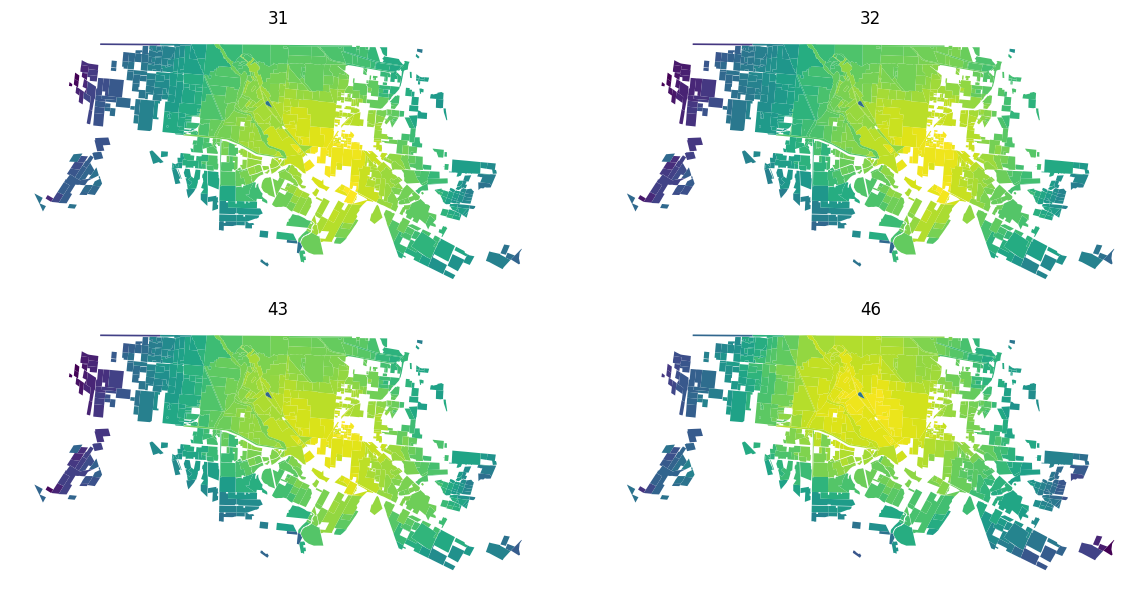

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for key, ax in zip(["31", "32", "43", "46"], axes.flatten(), strict=False):
    df_col.plot(column=f"jobs_{key}", ax=ax, legend=False)
    ax.axis("off")
    ax.set_title(key.capitalize())
fig.tight_layout()

### Services

In [ ]:
df_park = load_parks(data_path)

In [ ]:
df_col = df_col.drop(
    columns=["accessibility_all", "accessibility_parks"], errors="ignore"
).join(pd.DataFrame(response["result"]).transpose())

Submitting processing request...
Server acknowledged. Task ID: a5b939ec-708f-45cb-98e3-706a11eedb29
Worker finished. Received download ticket: a5b939ec-708f-45cb-98e3-706a11eedb29


<Axes: >

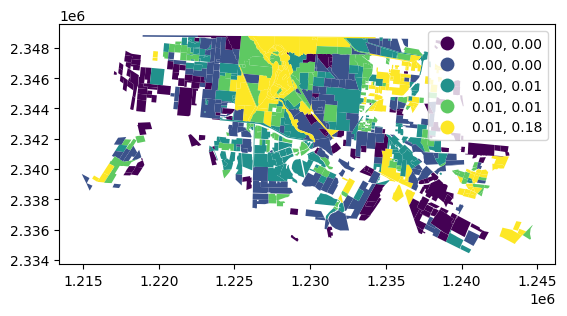

In [67]:
df_col.plot(column="accessibility_parks", scheme="quantiles", k=5, legend=True)

<Axes: >

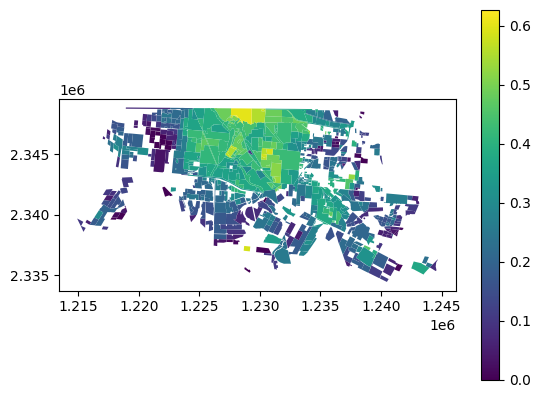

In [70]:
df_col.plot(column="accessibility_all", legend=True)

## Distance to city center

In [12]:
with engine.connect() as conn:
    city_center = gpd.read_postgis(
        """
        SELECT geometry FROM centroids_historical
        WHERE cve_met = '02.2.03'
        """,
        conn,
        geom_col="geometry",
    ).to_crs("EPSG:6372")

In [13]:
g = ox.graph_from_bbox(
    df_col.assign(geometry=lambda df: df["geometry"].buffer(5000))
    .to_crs("EPSG:4326")
    .total_bounds,
)
g = ox.add_edge_speeds(g)
g = ox.add_edge_travel_times(g)

In [14]:
cent = df_col.centroid.to_crs("EPSG:4326")
col_nodes = ox.nearest_nodes(g, cent.x, cent.y)

city_center_node = ox.nearest_nodes(
    g,
    city_center.to_crs("EPSG:4326")["geometry"].x,
    city_center.to_crs("EPSG:4326")["geometry"].y,
)[0]

In [15]:
shortest_paths = ox.shortest_path(
    g,
    col_nodes,
    [city_center_node] * len(col_nodes),
    weight="travel_time",
    cpus=8,
)
travel_times = [
    ox.routing.route_to_gdf(g, path, weight="travel_time")["travel_time"].sum()
    if path is not None
    else np.nan
    for path in shortest_paths
]
df_col = df_col.assign(travel_time_to_center=travel_times)

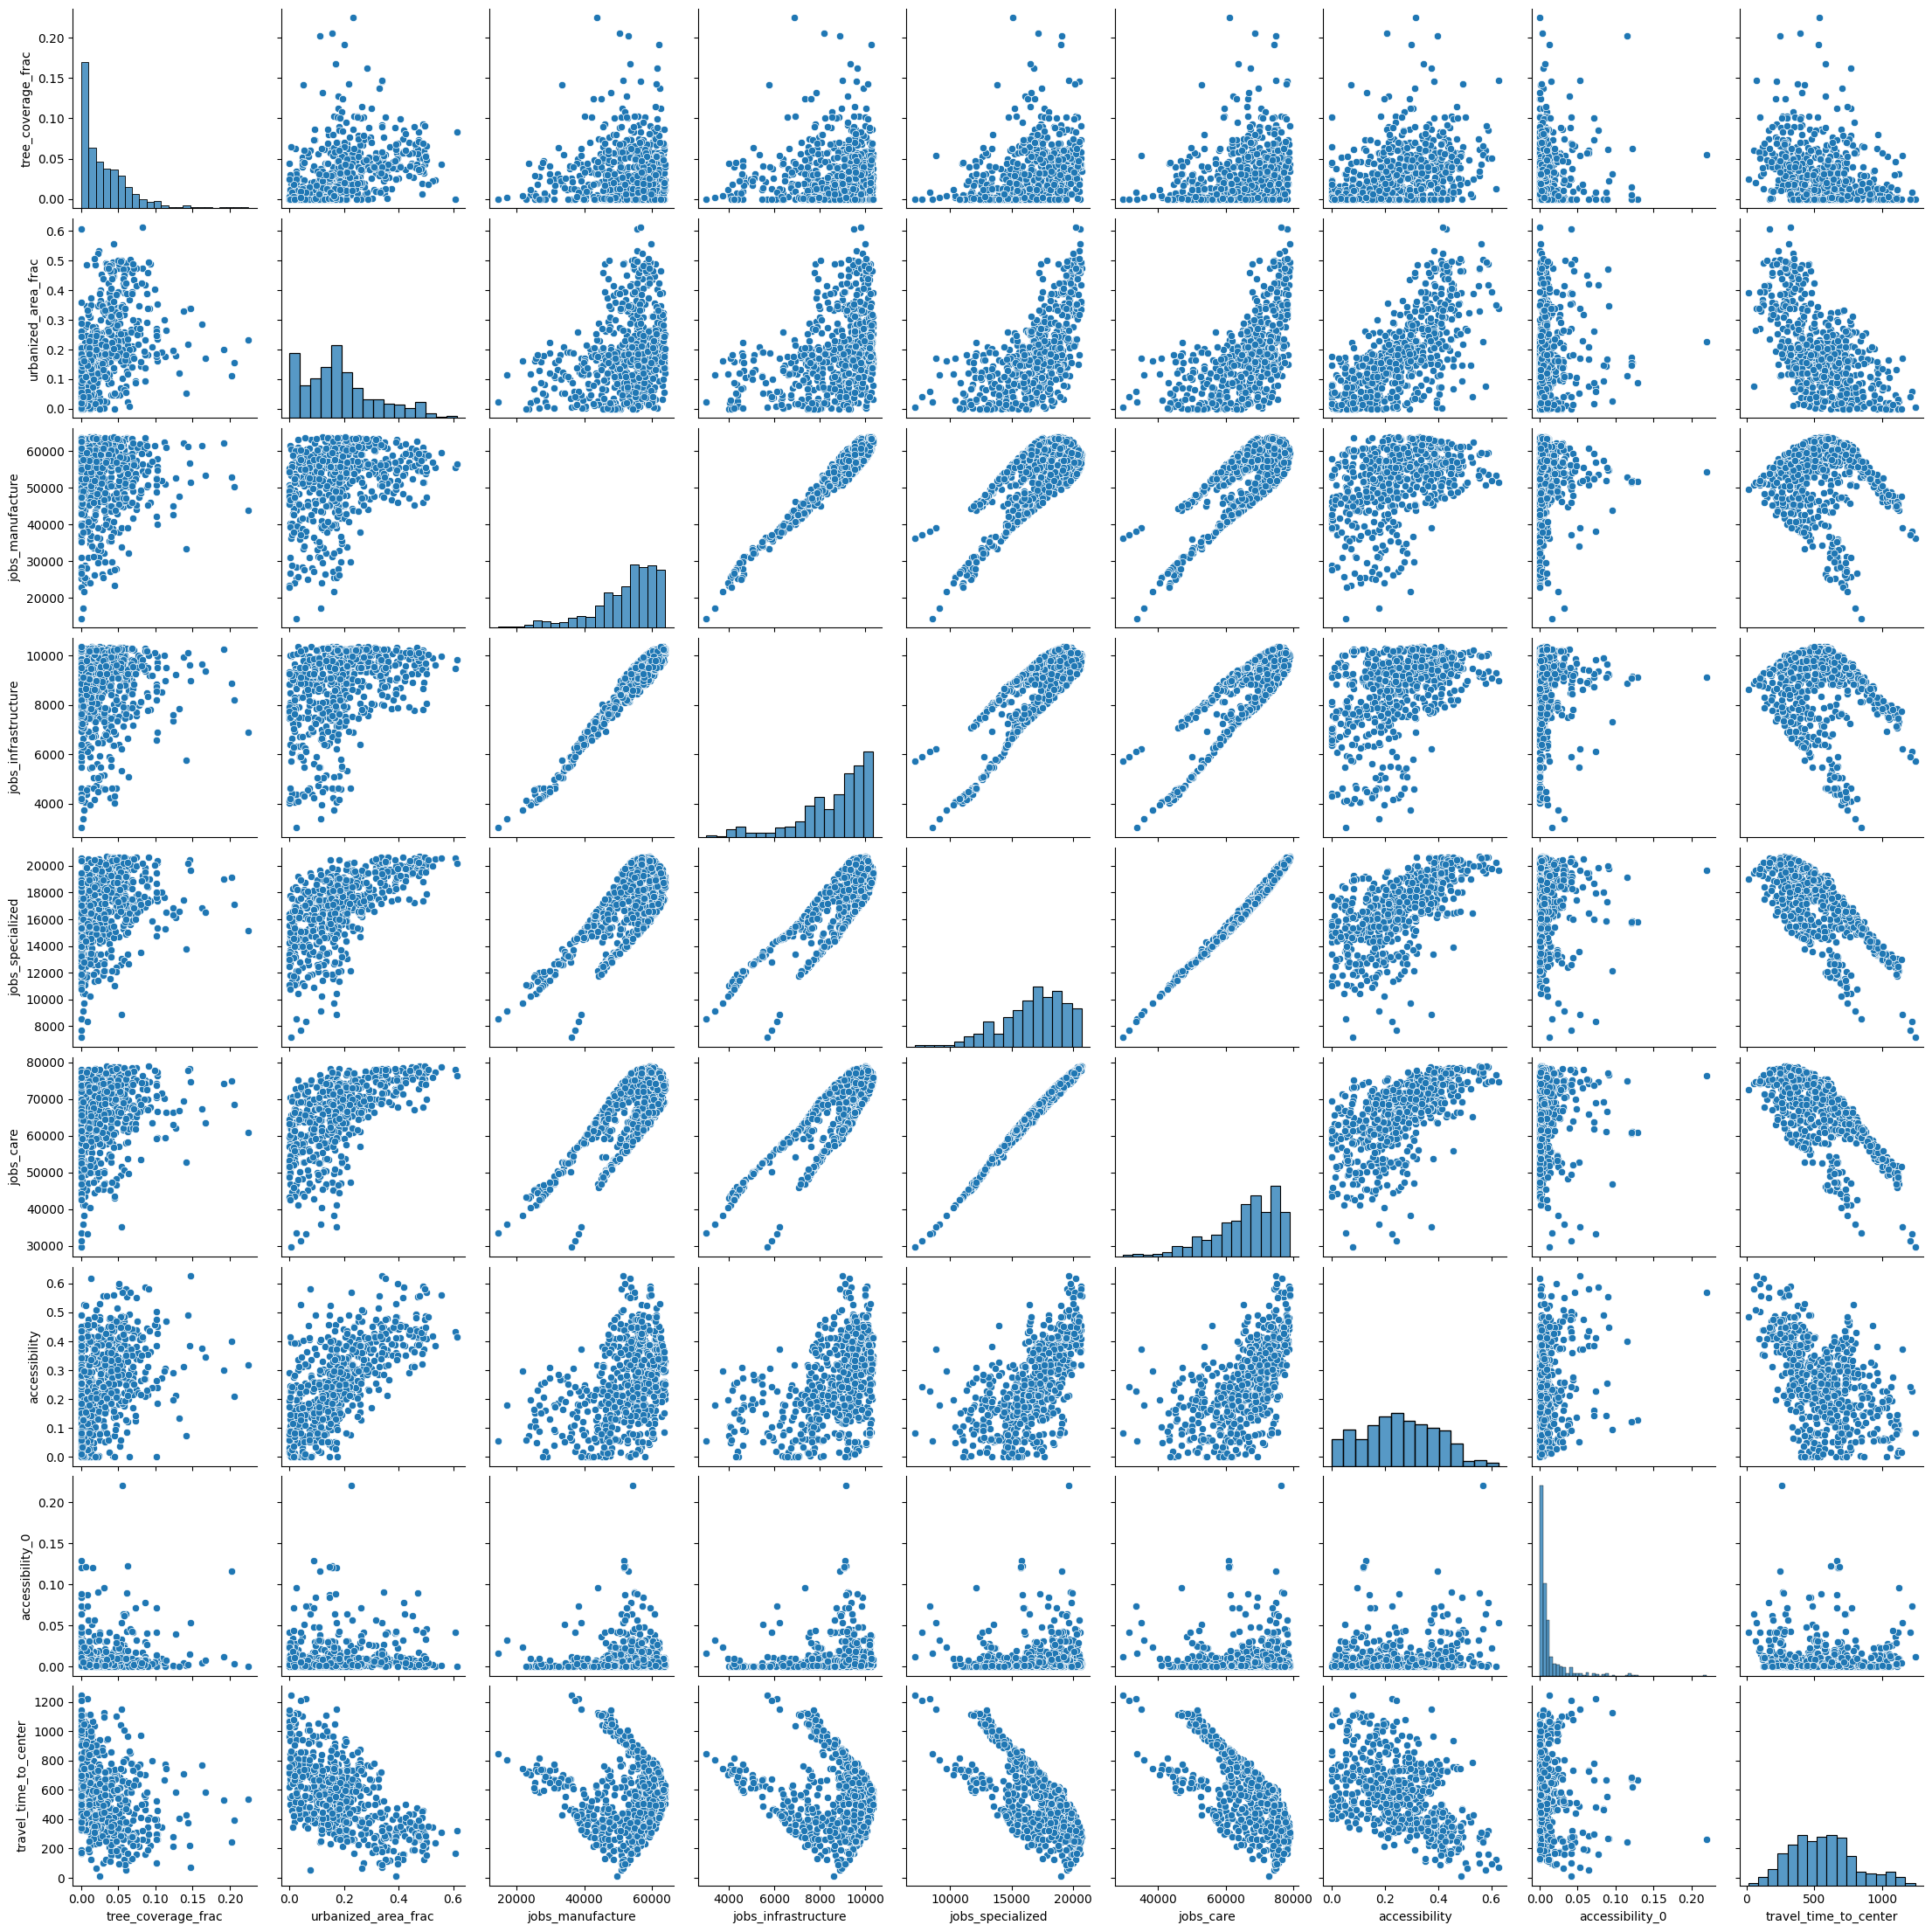

In [16]:
sns.pairplot(df_col.drop(columns=["geometry"]))

In [17]:
merged = df_orig[
    ["fraccionamiento", "fecha_operacion", "valor_operacion", "monto_credito"]
].merge(
    df_col.reset_index(names="fraccionamiento").drop(columns=["geometry"]),
    on="fraccionamiento",
    how="inner",
)

In [36]:
df_col.to_parquet("./frac_features.geoparquet")
df_orig.to_parquet("./transactions.parquet")

## Inmobiliaria

In [21]:
exe_frac = df_orig.loc[lambda df: df["mercado_exe"], "fraccionamiento"].unique()
df_col.loc[lambda df: df.index.isin(exe_frac), "is_exe"] = True
df_col = df_col.assign(is_exe=lambda df: df["is_exe"].fillna(False))

C:\Users\lain\AppData\Local\Temp\ipykernel_21996\474021561.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_col = df_col.assign(is_exe=lambda df: df["is_exe"].fillna(False))


# Plot

In [22]:
df_merge = df_orig.merge(
    df_col.reset_index(names="fraccionamiento"),
    on="fraccionamiento",
    how="left",
).pipe(gpd.GeoDataFrame, geometry="geometry", crs=df_col.crs)

<Axes: ylabel='privada'>

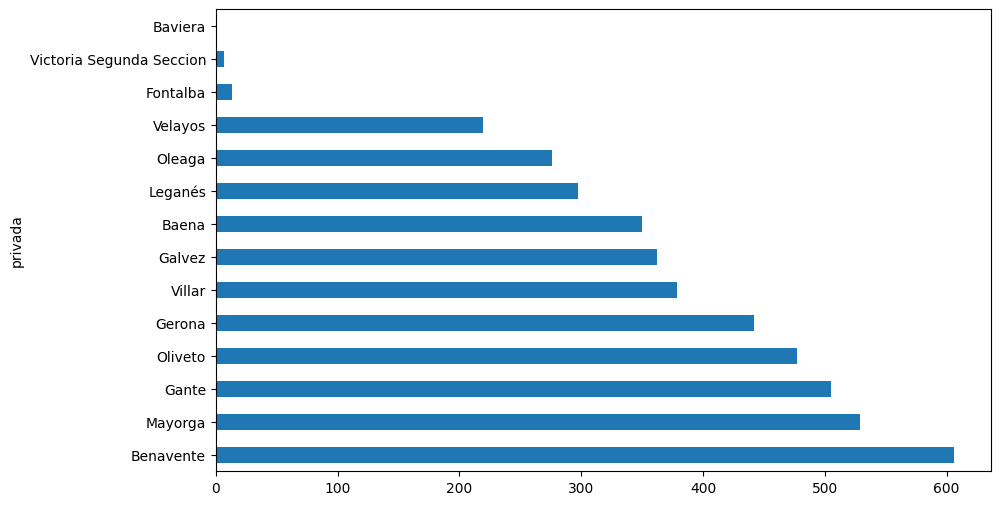

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
df_merge["privada"].str.title().value_counts().plot.barh(ax=ax)

FileNotFoundError: [Errno 2] No such file or directory: 'figures\\inmobiliarias.jpg'

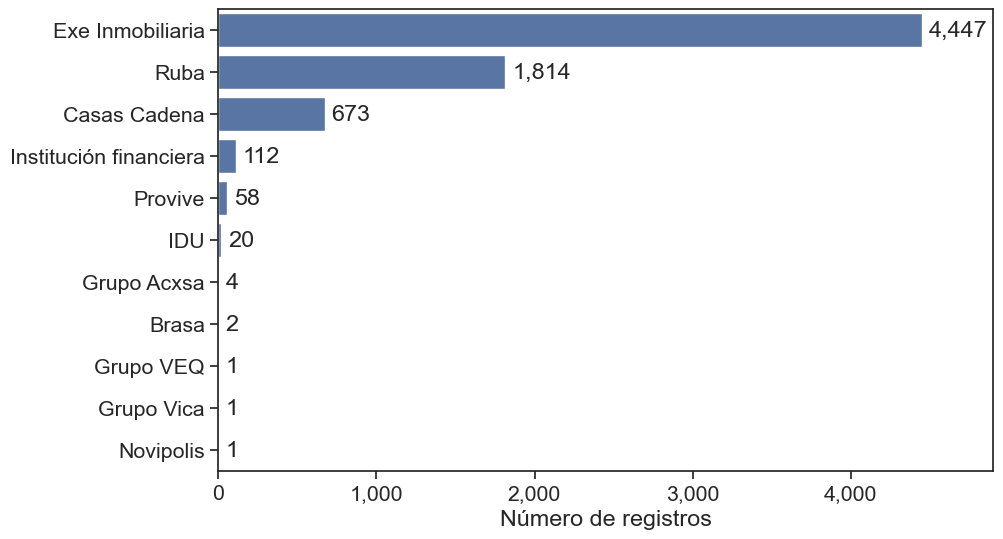

In [24]:
sns.set_theme(style="ticks", font_scale=1.4)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_orig["inmobiliaria"].value_counts(), ax=ax, orient="h")
ax.set_xlabel("Número de registros")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=5)
ax.set_xlim(0, 4900)
fig.savefig(figure_path / "inmobiliarias.jpg", bbox_inches="tight", dpi=300)

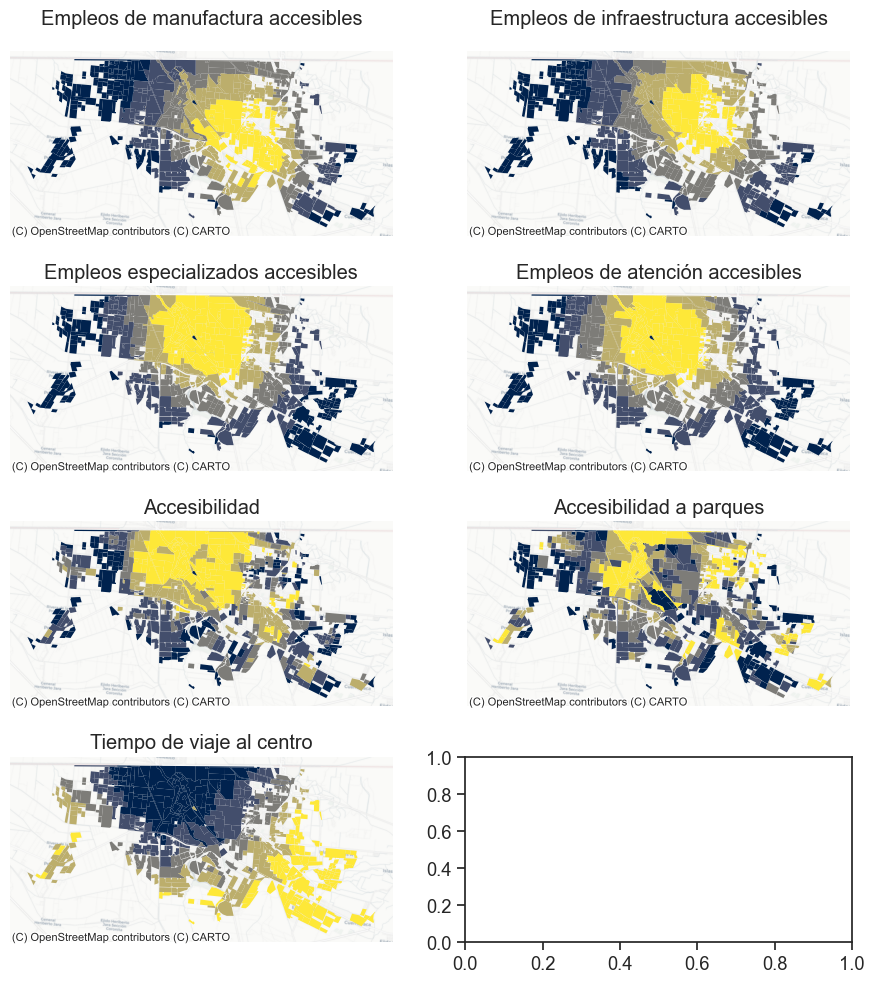

In [35]:
name_map = {
    "jobs_manufacture": "Empleos de manufactura accesibles",
    "jobs_infrastructure": "Empleos de infraestructura accesibles",
    "jobs_specialized": "Empleos especializados accesibles",
    "jobs_care": "Empleos de atención accesibles",
    "accessibility": "Accesibilidad",
    "accessibility_parks": "Accesibilidad a parques",
    "travel_time_to_center": "Tiempo de viaje al centro",
}

sns.set_theme(style="ticks", font_scale=1.2)

fig, axes = plt.subplots(4, 2, figsize=(9, 10))
for col, ax in zip(
    name_map.keys(),
    axes.flatten(),
):
    df_col.plot(column=col, ax=ax, lw=0, cmap="cividis", scheme="quantiles")
    ax.set_title(name_map[col])
    ax.axis("off")
    cx.add_basemap(ax, crs=df_col.crs, source=cx.providers.CartoDB.Positron, zoom=12)

fig.tight_layout()

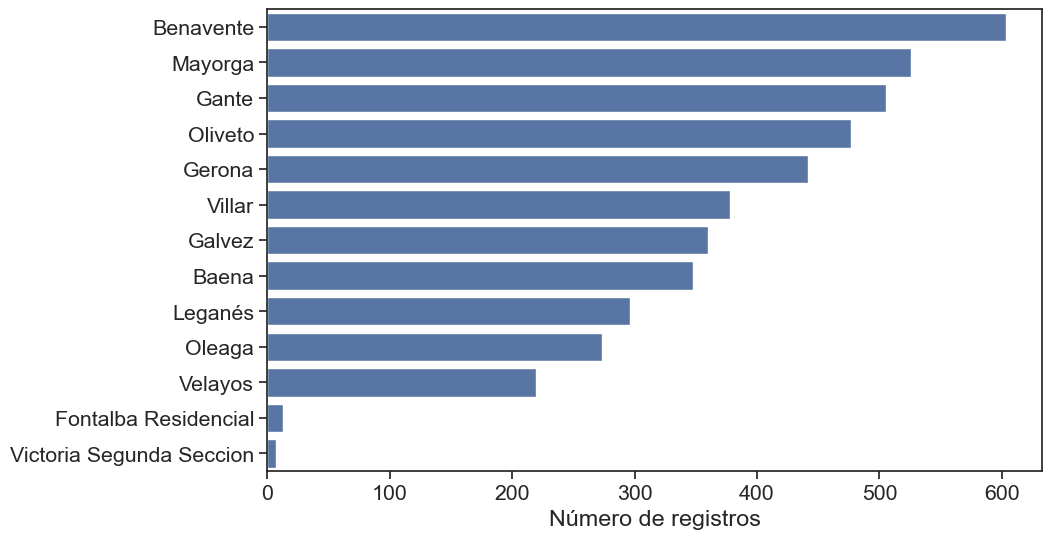

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_orig.loc[
        lambda df: df["inmobiliaria"].eq("Exe Inmobiliaria"),
        "fraccionamiento",
    ]
    .transform(
        lambda x: (
            x.str.replace("privadas condesa ", "")
            .str.replace("(", "")
            .str.replace(")", "")
            .str.title()
        ),
    )
    .value_counts(),
    ax=ax,
    orient="h",
)
ax.set_xlabel("Número de registros")
ax.set_ylabel("")
fig.savefig(figure_path / "exe_inmobiliaria.jpg", bbox_inches="tight", dpi=300)

In [ ]:
len(df_orig["fraccionamiento"].unique())

35

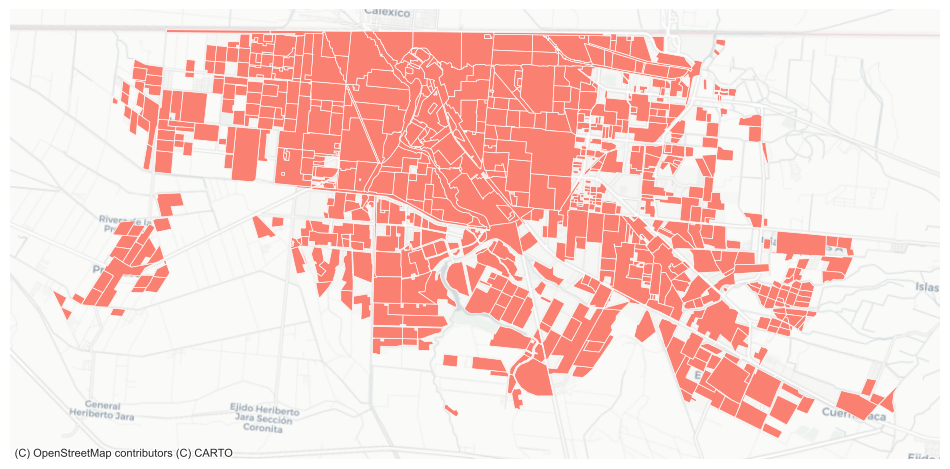

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
df_col.plot(ax=ax, fc="#FA8072", lw=0.5)
ax.axis("off")
cx.add_basemap(ax, crs=df_merge.crs, source=cx.providers.CartoDB.Positron, zoom=12)
fig.savefig(figure_path / "all_cols.jpg", bbox_inches="tight", dpi=300)

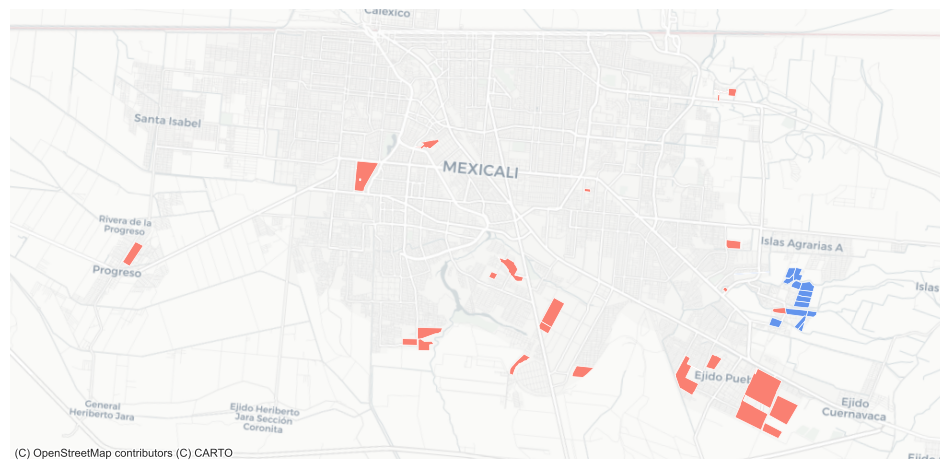

In [ ]:
xlim = ax.get_xlim()
ylim = ax.get_ylim()

temp = df_col.loc[lambda df: df.index.isin(df_orig["fraccionamiento"])]

fig, ax = plt.subplots(figsize=(12, 8))
temp.plot(
    ax=ax,
    column="is_exe",
    categorical=True,
    cmap=mcol.LinearSegmentedColormap.from_list("asd", ["#FA8072", "#6495ED"]),
    lw=0.5,
)
ax.axis("off")
cx.add_basemap(ax, crs=df_merge.crs, source=cx.providers.CartoDB.Positron, zoom=12)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

fig.savefig(figure_path / "registry_cols.jpg", bbox_inches="tight", dpi=300)

In [ ]:
df_col

,geometry,tree_coverage_frac,urbanized_area_frac,jobs,jobs_0,accessibility,travel_time_to_center,is_exe
COLONIAS,,,,,,,,
18 de marzo,"POLYGON ((1233389.196 2343271.04, 1233342.023 ...",0.056107,0.174922,241204.783967,57880.874261,0.324100,535.088783,False
27 de enero magisterial,"POLYGON ((1241329.668 2340408.209, 1241322.986...",0.004160,0.005316,171961.873828,43812.198884,0.119727,1082.647406,False
27 de septiembre,"POLYGON ((1225128.266 2345316.965, 1225110.735...",0.043113,0.340007,211810.321111,43198.625223,0.457595,263.645287,False
5 de julio,"POLYGON ((1231204.523 2340632.729, 1231181.797...",0.003377,0.054020,229047.205148,54269.749518,0.147189,535.818625,False
adara,"POLYGON ((1236092.844 2342634.529, 1236131.786...",0.000060,0.004049,227048.374252,56019.425899,0.395900,680.059325,False
...,...,...,...,...,...,...,...,...
xochimilco,"POLYGON ((1231292.147 2341852.507, 1231321.47 ...",0.029918,0.133111,236845.415217,55502.126685,0.244676,488.644784,False
zacatecas,"POLYGON ((1228960.313 2345239.214, 1228803.205...",0.047314,0.386534,242780.286421,51427.071036,0.470520,252.345085,False
zona industrial,"MULTIPOLYGON (((1230854.623 2342934.353, 12310...",0.033303,0.211268,239568.394743,51387.528938,0.427008,252.898619,False


In [ ]:
df_col.to_file("./test.gpkg")